## 1. Installation

In [20]:
!pip install librosa pyworld scipy scikit-learn tqdm numpy soundfile noisereduce

You should consider upgrading via the 'C:\Users\winni\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


## 2. Imports & Configuration

In [21]:
import os
import json
import random
import shutil
from pathlib import Path

import numpy as np
import librosa
import librosa.display
import pyworld as pw
import soundfile as sf
import noisereduce as nr
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import IPython.display as ipd

# ─────────────────────────────────────────────────────
# CHEMINS — adapte ESD_ROOT à ton environnement
# ─────────────────────────────────────────────────────
ESD_ROOT = r"C:\Users\winni\Downloads\Emotional Speech Dataset (ESD)\Emotion Speech Dataset"
OUT_DIR  = r"C:\Users\winni\Downloads\preprocessed"   # dossier de sortie

# ─────────────────────────────────────────────────────
# PARAMÈTRES AUDIO (identiques à FastSpeech2)
# ─────────────────────────────────────────────────────
SAMPLING_RATE  = 16000
HOP_LENGTH     = 256
WIN_LENGTH     = 1024
N_FFT          = 1024
N_MELS         = 128
MEL_FMIN       = 0
MEL_FMAX       = 8000

# ─────────────────────────────────────────────────────
# ÉMOTIONS
# ─────────────────────────────────────────────────────
EMOTION_MAP = {
    "Neutral":  0,
    "Happy":    1,
    "Angry":    2,
    "Sad":      3,
    "Surprise": 4,
}

# Locuteurs anglais : 0011 à 0020
SPEAKERS = [f"{i:04d}" for i in range(11, 21)]

VAL_SIZE = 100   # utterances réservées pour la validation

print("Configuration OK")
print(f"   ESD_ROOT : {ESD_ROOT}")
print(f"   OUT_DIR  : {OUT_DIR}")
print(f"   Speakers : {SPEAKERS}")

Configuration OK
   ESD_ROOT : C:\Users\winni\Downloads\Emotional Speech Dataset (ESD)\Emotion Speech Dataset
   OUT_DIR  : C:\Users\winni\Downloads\preprocessed
   Speakers : ['0011', '0012', '0013', '0014', '0015', '0016', '0017', '0018', '0019', '0020']


## 3. Exploration du dataset ESD

In [22]:
def explore_esd(esd_root, speakers):
    """Affiche la structure et statistiques du dataset."""
    total = 0
    emotions = list(EMOTION_MAP.keys())

    print(f"{'Speaker':<10}", end="")
    for e in emotions:
        print(f"{e:<12}", end="")
    print("Total")
    print("-" * (10 + 12 * len(emotions) + 6))

    for speaker in speakers:
        speaker_path = os.path.join(esd_root, speaker)
        if not os.path.isdir(speaker_path):
            print(f"{speaker:<10} ⚠️  introuvable")
            continue

        print(f"{speaker:<10}", end="")
        row_total = 0
        for emotion in emotions:
            count = 0
            for split in ["train", "evaluation", "test"]:
                split_path = os.path.join(speaker_path, emotion, split)
                if os.path.isdir(split_path):
                    count += len([f for f in os.listdir(split_path) if f.endswith(".wav")])
            print(f"{count:<12}", end="")
            row_total += count
        print(row_total)
        total += row_total

    print(f"\n Total fichiers WAV : {total}")
    return total

total = explore_esd(ESD_ROOT, SPEAKERS)

Speaker   Neutral     Happy       Angry       Sad         Surprise    Total
----------------------------------------------------------------------------
0011      0           0           0           0           0           0
0012      0           0           0           0           0           0
0013      0           0           0           0           0           0
0014      0           0           0           0           0           0
0015      0           0           0           0           0           0
0016      0           0           0           0           0           0
0017      0           0           0           0           0           0
0018      0           0           0           0           0           0
0019      0           0           0           0           0           0
0020      0           0           0           0           0           0

 Total fichiers WAV : 0


In [23]:
# Écoute d'un exemple par émotion
speaker = "0011"

for emotion in EMOTION_MAP.keys():
    split_path = os.path.join(ESD_ROOT, speaker, emotion, "train")
    if not os.path.isdir(split_path):
        continue
    wavs = [f for f in os.listdir(split_path) if f.endswith(".wav")]
    if wavs:
        wav_path = os.path.join(split_path, wavs[0])
        audio, sr = librosa.load(wav_path, sr=None)
        print(f"\n{emotion} — {wavs[0]} ({len(audio)/sr:.2f}s, {sr}Hz)")
        display(ipd.Audio(wav_path))

## 4. Fonctions de preprocessing (style FastSpeech2)

In [24]:
def load_transcriptions(esd_root, speaker):
    txt_path = os.path.join(esd_root, speaker, f"{speaker}.txt")
    transcriptions = {}
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(maxsplit=1)
            if len(parts) == 2:
                utt_id = parts[0]
                # Supprime l'émotion en fin de ligne (ex: "\tNeutral")
                text = parts[1].split("\t")[0].strip()
                transcriptions[utt_id] = text
    return transcriptions


def get_mel_and_energy(wav, sr):
    """
    Calcule le mel-spectrogramme et l'énergie frame-level.
    Reproduit la logique FastSpeech2 (TacotronSTFT).
    """
    mel = librosa.feature.melspectrogram(
        y=wav, sr=sr,
        n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        n_mels=N_MELS, fmin=MEL_FMIN, fmax=MEL_FMAX
    )
    mel_db = librosa.power_to_db(mel, ref=np.max).astype(np.float32)

    # Energy = norme L2 des frames STFT
    stft = librosa.stft(wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH)
    energy = np.sqrt(np.sum(np.abs(stft) ** 2, axis=0)).astype(np.float32)

    return mel_db, energy  # (N_MELS, T), (T,)


def get_pitch(wav, sr):
    """
    Extrait le pitch F0 avec PyWorld (même méthode que FastSpeech2).
    """
    pitch, t = pw.dio(
        wav.astype(np.float64), sr,
        frame_period=HOP_LENGTH / sr * 1000
    )
    pitch = pw.stonemask(wav.astype(np.float64), pitch, t, sr)
    return pitch.astype(np.float32)  # (T,)


def remove_outlier(values):
    """Supprime les outliers par méthode IQR (identique à FastSpeech2)."""
    values = np.array(values)
    p25, p75 = np.percentile(values, 25), np.percentile(values, 75)
    lower = p25 - 1.5 * (p75 - p25)
    upper = p75 + 1.5 * (p75 - p25)
    return values[np.logical_and(values > lower, values < upper)]


def normalize_dir(in_dir, mean, std):
    """Normalise tous les .npy d'un dossier (identique à FastSpeech2)."""
    max_val = np.finfo(np.float64).min
    min_val = np.finfo(np.float64).max
    for filename in os.listdir(in_dir):
        if not filename.endswith(".npy"):
            continue
        path = os.path.join(in_dir, filename)
        values = (np.load(path) - mean) / std
        np.save(path, values)
        max_val = max(max_val, float(np.max(values)))
        min_val = min(min_val, float(np.min(values)))
    return min_val, max_val

print(" Fonctions de preprocessing chargées")

 Fonctions de preprocessing chargées


In [25]:
def process_utterance(speaker, basename, emotion_id, emotion_name, wav_path, raw_text, out_dir):
    """
    Traite UN fichier audio :
      1. Charge et normalise le WAV
      2. Extrait pitch (PyWorld), mel-spectrogramme, energy
      3. Sauvegarde les .npy
    
    Retourne : (ligne_metadata, pitch_clean, energy_clean, n_frames)
    Format metadata : basename|speaker|emotion_id|raw_text
    """
    # ── Chargement audio ────────────────────────────────
    wav, _ = librosa.load(wav_path, sr=SAMPLING_RATE, mono=True)

    # Trim silences début/fin
    wav, _ = librosa.effects.trim(wav, top_db=25)

    # Normalisation amplitude
    wav = wav / (np.max(np.abs(wav)) + 1e-8)

    # ── Pitch F0 (PyWorld) ──────────────────────────────
    pitch = get_pitch(wav, SAMPLING_RATE)
    if np.sum(pitch != 0) <= 1:
        return None   # fichier inutilisable

    # ── Mel + Energy ─────────────────────────────────────
    mel, energy = get_mel_and_energy(wav, SAMPLING_RATE)

    # Aligne les longueurs
    min_len = min(mel.shape[1], len(pitch), len(energy))
    mel     = mel[:, :min_len]
    pitch   = pitch[:min_len]
    energy  = energy[:min_len]

    # ── Sauvegarde .npy ──────────────────────────────────
    tag = f"{speaker}-{emotion_name}-{basename}"
    np.save(os.path.join(out_dir, "mel",    f"{tag}-mel.npy"),    mel.T)   # (T, N_MELS)
    np.save(os.path.join(out_dir, "pitch",  f"{tag}-pitch.npy"),  pitch)
    np.save(os.path.join(out_dir, "energy", f"{tag}-energy.npy"), energy)

    # Format : basename|speaker|emotion_id|raw_text
    metadata = "|".join([basename, speaker, str(emotion_id), raw_text])

    return metadata, remove_outlier(pitch), remove_outlier(energy), mel.shape[1]

print("process_utterance chargée")

process_utterance chargée


## 5. Pipeline principal — Condition CLEAN

In [ ]:
def build_dataset(esd_root, out_dir, speakers, label="clean",
                  pitch_normalization=True, energy_normalization=True):

    for d in ["mel", "pitch", "energy"]:
        os.makedirs(os.path.join(out_dir, d), exist_ok=True)

    out           = []
    n_frames      = 0
    skipped       = 0
    pitch_scaler  = StandardScaler()
    energy_scaler = StandardScaler()
    speakers_dict = {}

    for i, speaker in enumerate(tqdm(speakers, desc="Speakers")):
        speaker_path = os.path.join(esd_root, speaker)
        if not os.path.isdir(speaker_path):
            continue

        speakers_dict[speaker] = i
        transcriptions = load_transcriptions(esd_root, speaker)

        for emotion_name, emotion_id in EMOTION_MAP.items():
            emotion_path = os.path.join(speaker_path, emotion_name)
            if not os.path.isdir(emotion_path):
                continue

            for wav_name in os.listdir(emotion_path):
                if not wav_name.endswith(".wav"):
                    continue

                basename = wav_name.replace(".wav", "")
                raw_text = transcriptions.get(basename, "")
                if not raw_text:
                    skipped += 1
                    continue

                wav_path = os.path.join(emotion_path, wav_name)
                ret = process_utterance(
                    speaker, basename, emotion_id, emotion_name,
                    wav_path, raw_text, out_dir
                )
                if ret is None:
                    skipped += 1
                    continue

                metadata, pitch, energy, n = ret
                out.append(metadata)

                if len(pitch) > 0:
                    pitch_scaler.partial_fit(pitch.reshape(-1, 1))
                if len(energy) > 0:
                    energy_scaler.partial_fit(energy.reshape(-1, 1))
                n_frames += n

    # Normalisation
    print("\nNormalisation pitch & energy...")
    pitch_mean  = pitch_scaler.mean_[0]  if pitch_normalization  else 0
    pitch_std   = pitch_scaler.scale_[0] if pitch_normalization  else 1
    energy_mean = energy_scaler.mean_[0] if energy_normalization else 0
    energy_std  = energy_scaler.scale_[0]if energy_normalization else 1

    pitch_min,  pitch_max  = normalize_dir(os.path.join(out_dir, "pitch"),  pitch_mean,  pitch_std)
    energy_min, energy_max = normalize_dir(os.path.join(out_dir, "energy"), energy_mean, energy_std)

    with open(os.path.join(out_dir, "speakers.json"), "w") as f:
        json.dump(speakers_dict, f, indent=2)

    with open(os.path.join(out_dir, "stats.json"), "w") as f:
        json.dump({
            "pitch":  [float(pitch_min), float(pitch_max), float(pitch_mean), float(pitch_std)],
            "energy": [float(energy_min), float(energy_max), float(energy_mean), float(energy_std)],
        }, f, indent=2)

    random.shuffle(out)
    out = [r for r in out if r is not None]

    with open(os.path.join(out_dir, "train.txt"), "w", encoding="utf-8") as f:
        for m in out[VAL_SIZE:]:
            f.write(m + "\n")
    with open(os.path.join(out_dir, "val.txt"), "w", encoding="utf-8") as f:
        for m in out[:VAL_SIZE]:
            f.write(m + "\n")

    h = n_frames * HOP_LENGTH / SAMPLING_RATE / 3600
    print(f"\n Preprocessing [{label}] terminé")
    print(f"   Utterances traitées : {len(out)}")
    print(f"   Utterances ignorées : {skipped}")
    print(f"   Durée totale audio  : {h:.2f}h")
    print(f"   Train / Val         : {len(out) - VAL_SIZE} / {VAL_SIZE}")

    return out

In [9]:
!pip install ipywidgets

You should consider upgrading via the 'C:\Users\winni\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [35]:
# Lance le preprocessing sur les données CLEAN
CLEAN_OUT = os.path.join(OUT_DIR, "clean")

out_clean = build_dataset(
    esd_root=ESD_ROOT,
    out_dir=CLEAN_OUT,
    speakers=SPEAKERS,
    label="clean"
)


Exception ignored in: <function tqdm.__del__ at 0x0000020EC254B760>
Traceback (most recent call last):
  File "c:\Users\winni\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\winni\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Exception ignored in: <function tqdm.__del__ at 0x0000020EC254B760>
Traceback (most recent call last):
  File "c:\Users\winni\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\std.py", line 1148, in __del__
    self.close()
  File "c:\Users\winni\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'










Speakers: 100%|██████████| 10/10 [11:22<00:00


Normalisation pitch & energy...

✅ Preprocessing [clean] terminé
   Utterances traitées : 17499
   Utterances ignorées : 1
   Durée totale audio  : 10.25h
   Train / Val         : 17399 / 100


## 6. Condition dégradée — ajout de bruit (plan d'expérience)

In [ ]:
def add_gaussian_noise(wav, snr_db=10):
    """
    Ajoute du bruit blanc gaussien à un signal audio
    avec un rapport signal/bruit (SNR) cible en dB.
    """
    signal_power = np.mean(wav ** 2)
    noise_power  = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), wav.shape)
    return (wav + noise).astype(np.float32)


def create_noisy_esd(esd_root, noisy_root, speakers, snr_db=10):
    os.makedirs(noisy_root, exist_ok=True)
    total = 0

    for speaker in tqdm(speakers, desc="Speakers"):
        txt_src     = os.path.join(esd_root, speaker, f"{speaker}.txt")
        speaker_dst = os.path.join(noisy_root, speaker)
        os.makedirs(speaker_dst, exist_ok=True)
        shutil.copy2(txt_src, os.path.join(speaker_dst, f"{speaker}.txt"))

        for emotion_name in EMOTION_MAP.keys():
            emotion_src = os.path.join(esd_root, speaker, emotion_name)
            emotion_dst = os.path.join(noisy_root, speaker, emotion_name)
            if not os.path.isdir(emotion_src):
                continue
            os.makedirs(emotion_dst, exist_ok=True)

            for wav_name in os.listdir(emotion_src):   # ← bien indenté ici
                if not wav_name.endswith(".wav"):
                    continue
                wav, _ = librosa.load(
                    os.path.join(emotion_src, wav_name), sr=SAMPLING_RATE
                )
                wav_noisy = add_gaussian_noise(wav, snr_db=snr_db)
                sf.write(os.path.join(emotion_dst, wav_name), wav_noisy, SAMPLING_RATE)
                total += 1

    print(f"\n Dataset bruité créé : {total} fichiers")
    print(f"   SNR cible : {snr_db} dB")
    print(f"   Dossier   : {noisy_root}")


# Lance la génération
NOISY_ESD_ROOT = r"C:\Users\winni\Downloads\ESD_noisy"
SNR_DB = 10
create_noisy_esd(ESD_ROOT, NOISY_ESD_ROOT, SPEAKERS, snr_db=SNR_DB)

Speakers: 100%|██████████| 10/10 [02:11<00:00, 13.16s/it]


✅ Dataset bruité créé : 17500 fichiers
   SNR cible : 10 dB
   Dossier   : C:\Users\winni\Downloads\ESD_noisy


In [37]:
# Lance le preprocessing sur les données BRUITÉES
NOISY_OUT = os.path.join(OUT_DIR, "noisy")

out_noisy = build_dataset(
    esd_root=NOISY_ESD_ROOT,
    out_dir=NOISY_OUT,
    speakers=SPEAKERS,
    label="noisy"
)

Speakers: 100%|██████████| 10/10 [44:24<00:00, 266.48s/it]



Normalisation pitch & energy...

✅ Preprocessing [noisy] terminé
   Utterances traitées : 17480
   Utterances ignorées : 20
   Durée totale audio  : 13.44h
   Train / Val         : 17380 / 100


## 7. Vérification & Visualisations

In [38]:
def verify_outputs(out_dir, label="clean"):
    """Vérifie les fichiers générés et affiche des statistiques."""
    mel_dir    = os.path.join(out_dir, "mel")
    pitch_dir  = os.path.join(out_dir, "pitch")
    energy_dir = os.path.join(out_dir, "energy")

    n_mel    = len([f for f in os.listdir(mel_dir)    if f.endswith(".npy")])
    n_pitch  = len([f for f in os.listdir(pitch_dir)  if f.endswith(".npy")])
    n_energy = len([f for f in os.listdir(energy_dir) if f.endswith(".npy")])

    print(f"=== Vérification [{label}] ===")
    print(f"   Fichiers mel    : {n_mel}")
    print(f"   Fichiers pitch  : {n_pitch}")
    print(f"   Fichiers energy : {n_energy}")

    # Affiche le stats.json
    stats_path = os.path.join(out_dir, "stats.json")
    if os.path.exists(stats_path):
        with open(stats_path) as f:
            stats = json.load(f)
        print(f"\n   stats.json :")
        print(f"   pitch  → min={stats['pitch'][0]:.3f} max={stats['pitch'][1]:.3f} "
              f"mean={stats['pitch'][2]:.3f} std={stats['pitch'][3]:.3f}")
        print(f"   energy → min={stats['energy'][0]:.3f} max={stats['energy'][1]:.3f} "
              f"mean={stats['energy'][2]:.3f} std={stats['energy'][3]:.3f}")

    # Affiche les premières lignes de train.txt
    train_path = os.path.join(out_dir, "train.txt")
    if os.path.exists(train_path):
        with open(train_path) as f:
            lines = f.readlines()
        print(f"\n   train.txt ({len(lines)} lignes) — format : basename|speaker|emotion_id|text")
        for line in lines[:3]:
            print(f"   {line.strip()}")

verify_outputs(CLEAN_OUT, "clean")

=== Vérification [clean] ===
   Fichiers mel    : 17499
   Fichiers pitch  : 17499
   Fichiers energy : 17499

   stats.json :
   pitch  → min=-1.091 max=5.950 mean=130.108 std=119.283
   energy → min=-1.114 max=8.019 mean=44.100 std=39.572

   train.txt (17399 lignes) — format : basename|speaker|emotion_id|text
   0019_001261|0019|3|From each cake, there sprang a huge dog.
   0015_000394|0015|2|Take courage all isn't lost yet.
   0015_000430|0015|2|Then there was a report.


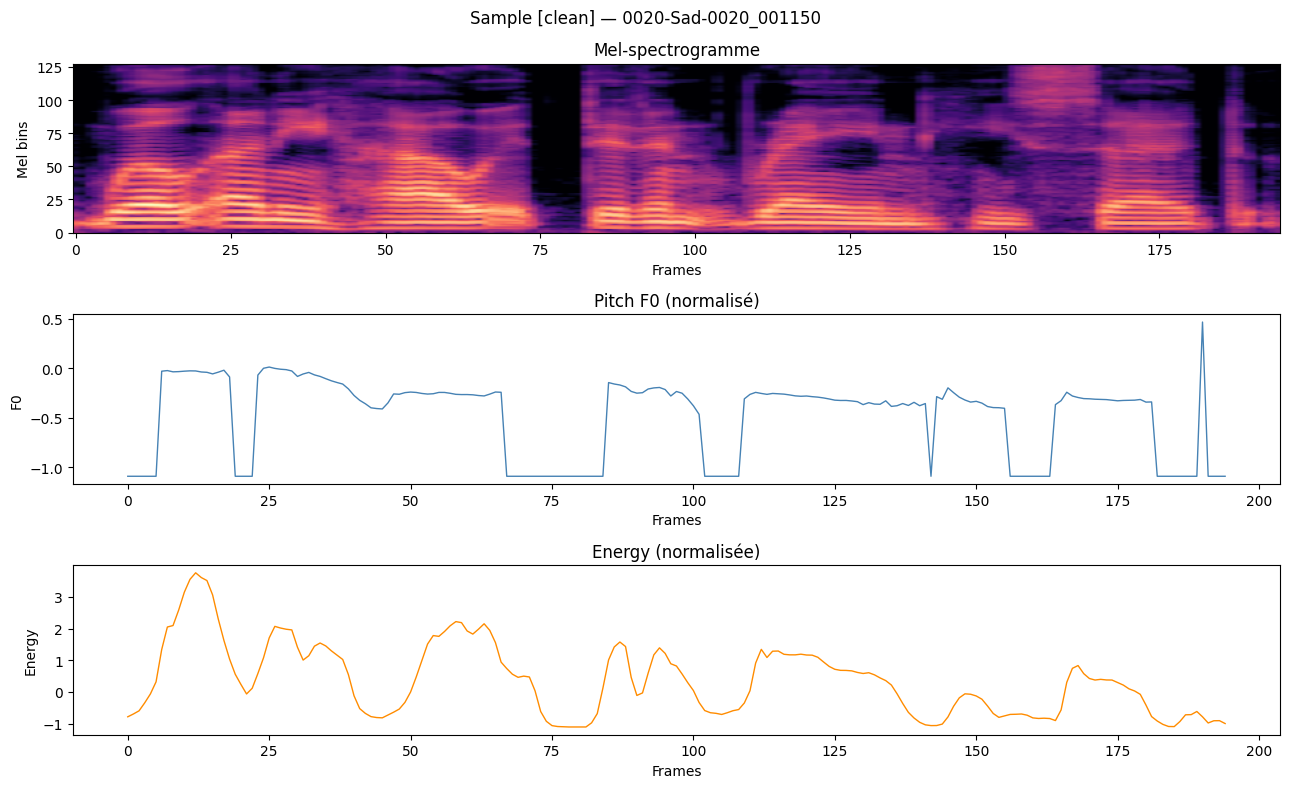

In [39]:
def visualize_sample(out_dir, label="clean"):
    """Visualise mel, pitch et energy d'un sample aléatoire."""
    mel_dir   = os.path.join(out_dir, "mel")
    mel_files = [f for f in os.listdir(mel_dir) if f.endswith(".npy")]
    if not mel_files:
        print("Aucun fichier mel trouvé.")
        return

    sample = random.choice(mel_files)
    tag    = sample.replace("-mel.npy", "")

    mel    = np.load(os.path.join(out_dir, "mel",    f"{tag}-mel.npy"))    # (T, N_MELS)
    pitch  = np.load(os.path.join(out_dir, "pitch",  f"{tag}-pitch.npy"))  # (T,)
    energy = np.load(os.path.join(out_dir, "energy", f"{tag}-energy.npy")) # (T,)

    fig, axes = plt.subplots(3, 1, figsize=(13, 8))
    fig.suptitle(f"Sample [{label}] — {tag}", fontsize=12)

    axes[0].imshow(mel.T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title("Mel-spectrogramme")
    axes[0].set_ylabel("Mel bins")
    axes[0].set_xlabel("Frames")

    axes[1].plot(pitch, color="steelblue", linewidth=1)
    axes[1].set_title("Pitch F0 (normalisé)")
    axes[1].set_ylabel("F0")
    axes[1].set_xlabel("Frames")

    axes[2].plot(energy, color="darkorange", linewidth=1)
    axes[2].set_title("Energy (normalisée)")
    axes[2].set_ylabel("Energy")
    axes[2].set_xlabel("Frames")

    plt.tight_layout()
    plt.show()

visualize_sample(CLEAN_OUT, "clean")

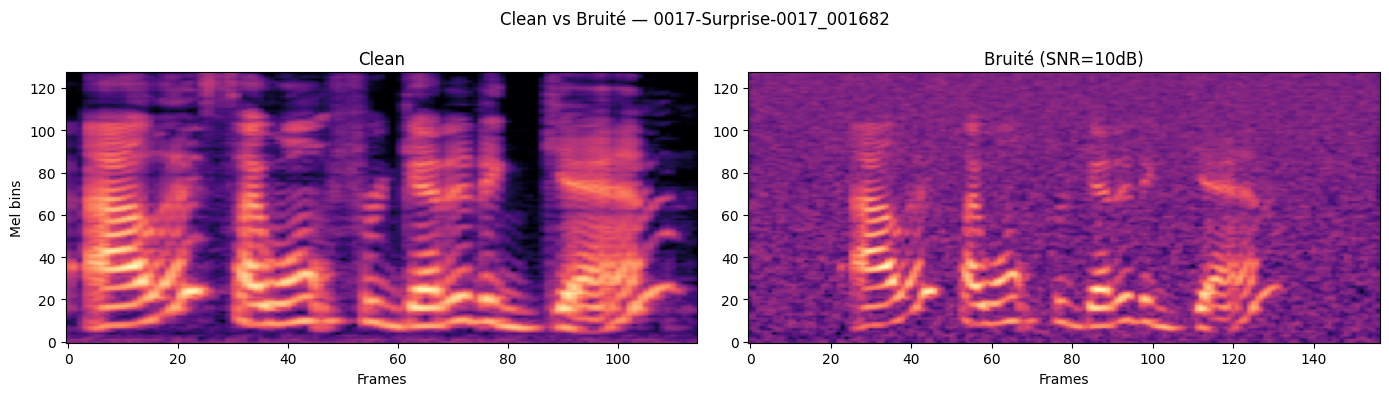

In [40]:
def compare_clean_noisy(clean_dir, noisy_dir):
    """Compare visuellement un même sample clean vs bruité."""
    mel_files = [f for f in os.listdir(os.path.join(clean_dir, "mel")) if f.endswith(".npy")]
    sample    = random.choice(mel_files)
    tag       = sample.replace("-mel.npy", "")

    mel_clean = np.load(os.path.join(clean_dir, "mel", f"{tag}-mel.npy"))
    mel_noisy = np.load(os.path.join(noisy_dir, "mel", f"{tag}-mel.npy"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Clean vs Bruité — {tag}", fontsize=12)

    axes[0].imshow(mel_clean.T, aspect="auto", origin="lower", cmap="magma")
    axes[0].set_title("Clean")
    axes[0].set_ylabel("Mel bins")
    axes[0].set_xlabel("Frames")

    axes[1].imshow(mel_noisy.T, aspect="auto", origin="lower", cmap="magma")
    axes[1].set_title(f"Bruité (SNR={SNR_DB}dB)")
    axes[1].set_xlabel("Frames")

    plt.tight_layout()
    plt.show()

compare_clean_noisy(CLEAN_OUT, NOISY_OUT)

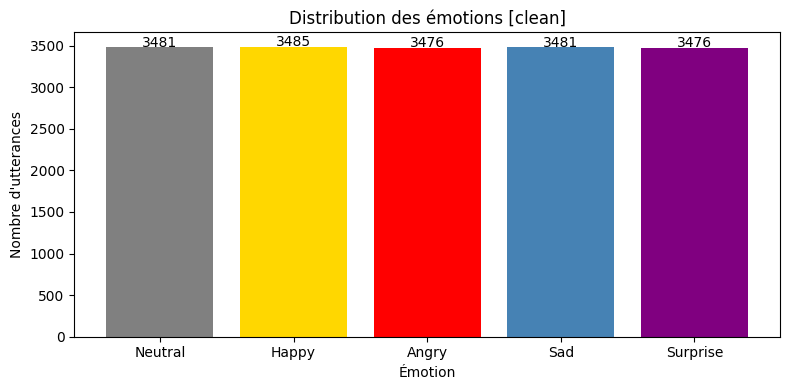

In [41]:
def distribution_emotions(out_dir, label="clean"):
    """Affiche la distribution des émotions dans le dataset preprocessé."""
    train_path = os.path.join(out_dir, "train.txt")
    counts = {name: 0 for name in EMOTION_MAP}
    id_to_name = {v: k for k, v in EMOTION_MAP.items()}

    with open(train_path, encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("|")
            if len(parts) >= 3:
                emotion_id = int(parts[2])
                name = id_to_name.get(emotion_id, "Unknown")
                counts[name] += 1

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(counts.keys(), counts.values(),
           color=["gray", "gold", "red", "steelblue", "purple"])
    ax.set_title(f"Distribution des émotions [{label}]")
    ax.set_ylabel("Nombre d'utterances")
    ax.set_xlabel("Émotion")
    for i, (k, v) in enumerate(counts.items()):
        ax.text(i, v + 5, str(v), ha="center", fontsize=10)
    plt.tight_layout()
    plt.show()

distribution_emotions(CLEAN_OUT, "clean")

## Récapitulatif

```
ESD brut                         →   preprocessed/
──────────────────────────────────────────────────────
speaker/emotion/split/*.wav           clean/
speaker/speaker.txt              ├── mel/      *.npy  (T × 128)
                                 ├── pitch/    *.npy  (T,) normalisé
                                 ├── energy/   *.npy  (T,) normalisé
                                 ├── train.txt  basename|speaker|emotion_id|text
                                 ├── val.txt
                                 ├── speakers.json
                                 └── stats.json

ESD + bruit blanc (SNR=10dB)          noisy/
                                 └── (même structure)
```

**Format metadata (train.txt / val.txt) :**
```
0011_000001|0011|1|This is the text of the utterance
basename   |spkr|emotion_id (0=Neutral,1=Happy,2=Angry,3=Sad,4=Surprise)|texte
```